In [1]:
import numpy as np

states = ['h', 'e', 'l', 'o']
observations = ['O1', 'O2', 'O3', 'O4']

# Transition Probability Matrix
A = np.array([[0.0, 0.7, 0.3, 0.0],
              [0.0, 0.2, 0.6, 0.2],
              [0.0, 0.0, 0.3, 0.7],
              [0.0, 0.0, 0.1, 0.9]])

# Emission Probability Matrix
B = np.array([[0.6, 0.2, 0.1, 0.1],
              [0.1, 0.7, 0.1, 0.1],
              [0.1, 0.1, 0.6, 0.2],
              [0.2, 0.1, 0.2, 0.5]])

# Initial Probabilities
pi = np.array([1, 0, 0, 0])

# Number of observations and states
T = len(observations)
N = len(states)

# Initialize matrices
P = np.zeros((N, T)) # Probability matrix
Q = np.zeros((N, T), dtype=int) # Path matrix

# Initialization step
for s in range(N):
    P[s][0] = pi[s] * B[s][observations.index('O1')]

# Recursion step
for t in range(1, T):
    for s in range(N):
        max_prob = -1
        max_state = -1
        for s_prev in range(N):
            prob = P[s_prev][t-1] * A[s_prev][s] * B[s][observations.index(f'O{t+1}')]
            if prob > max_prob:
                max_prob = prob
                max_state = s_prev
        P[s][t] = max_prob
        Q[s][t] = max_state

# Termination step
max_final_prob = -1
best_last_state = -1
for s in range(N):
    if P[s][T-1] > max_final_prob:
        max_final_prob = P[s][T-1]
        best_last_state = s

# Backtrack to find the best path
best_path = []
current_state = best_last_state
for t in range(T-1, -1, -1):
    best_path.append(states[current_state])
    current_state = Q[current_state][t]

best_path.reverse()

print("Most likely sequence of phoneme states:", best_path)
print("Probability of the most likely sequence:", max_final_prob)

Most likely sequence of phoneme states: ['h', 'e', 'l', 'o']
Probability of the most likely sequence: 0.03704399999999999


In [4]:
from math import log
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

display(Markdown("# Viterbi Algorithm Based Phoneme Decoding – *hello*"))

states = ["S1(/h/)", "S2(/e/)", "S3(/l/)", "S4(/o/)"]
observations = ["O1", "O2", "O3", "O4"]

display(Markdown("**States:** /h/, /e/, /l/, /o/"))
display(Markdown("**Observation sequence:** O1 → O2 → O3 → O4"))

# Initial Probabilities π
pi = np.array([1.0, 0.0, 0.0, 0.0])

# Transition Probability Matrix A
A = np.array([
    [0.10, 0.85, 0.03, 0.02],
    [0.02, 0.10, 0.85, 0.03],
    [0.01, 0.03, 0.10, 0.86],
    [0.00, 0.00, 0.00, 1.00]
])

# Emission Probability Matrix B
B = np.array([
    [0.90, 0.03, 0.04, 0.03],
    [0.02, 0.92, 0.03, 0.03],
    [0.03, 0.02, 0.92, 0.03],
    [0.02, 0.03, 0.05, 0.90]
])

display(Markdown("### Transition Matrix A"))
display(pd.DataFrame(A, index=states, columns=states))

display(Markdown("### Emission Matrix B"))
display(pd.DataFrame(B, index=states, columns=observations))


# Viterbi Algorithm Based Phoneme Decoding – *hello*

**States:** /h/, /e/, /l/, /o/

**Observation sequence:** O1 → O2 → O3 → O4

### Transition Matrix A

,S1(/h/),S2(/e/),S3(/l/),S4(/o/)
S1(/h/),0.10,0.85,0.03,0.02
S2(/e/),0.02,0.10,0.85,0.03
S3(/l/),0.01,0.03,0.10,0.86
S4(/o/),0.00,0.00,0.00,1.00


### Emission Matrix B

,O1,O2,O3,O4
S1(/h/),0.90,0.03,0.04,0.03
S2(/e/),0.02,0.92,0.03,0.03
S3(/l/),0.03,0.02,0.92,0.03
S4(/o/),0.02,0.03,0.05,0.90


In [5]:
display(Markdown("## 2) Viterbi Algorithm Implementation"))

def viterbi_log(pi, A, B, obs_seq):
    N = A.shape[0]
    T = len(obs_seq)

    log_pi = np.log(pi)
    log_A = np.log(A)
    log_B = np.log(B)

    delta = np.full((T, N), -np.inf)
    psi = np.zeros((T, N), dtype=int)

    # Initialization
    for i in range(N):
        delta[0, i] = log_pi[i] + log_B[i, obs_seq[0]]

    # Recursion
    for t in range(1, T):
        for j in range(N):
            vals = delta[t-1] + log_A[:, j]
            psi[t, j] = np.argmax(vals)
            delta[t, j] = np.max(vals) + log_B[j, obs_seq[t]]

    # Termination
    best_last_state = np.argmax(delta[-1])
    best_log_prob = delta[-1, best_last_state]

    # Backtracking
    path = [best_last_state]
    for t in range(T-1, 0, -1):
        path.insert(0, psi[t, path[0]])

    return path, best_log_prob, delta, psi

# Observation sequence O1 O2 O3 O4 → indices 0 1 2 3
obs_seq = [0, 1, 2, 3]

path_idx, best_logprob, delta_log, psi = viterbi_log(pi, A, B, obs_seq)
decoded_states = [states[i] for i in path_idx]
best_prob = np.exp(best_logprob)

print("\n=== VITERBI RESULTS ===")
print("Most likely phoneme sequence:", decoded_states)
print("Log probability:", best_logprob)
print("Probability:", best_prob)

## 2) Viterbi Algorithm Implementation


=== VITERBI RESULTS ===
Most likely phoneme sequence: ['S1(/h/)', 'S2(/e/)', 'S3(/l/)', 'S4(/o/)']
Log probability: -0.8533449979238881
Probability: 0.42598761840000005


/tmp/ipython-input-1568519612.py:7: RuntimeWarning: divide by zero encountered in log
  log_pi = np.log(pi)
/tmp/ipython-input-1568519612.py:8: RuntimeWarning: divide by zero encountered in log
  log_A = np.log(A)


## 3) Visualizations

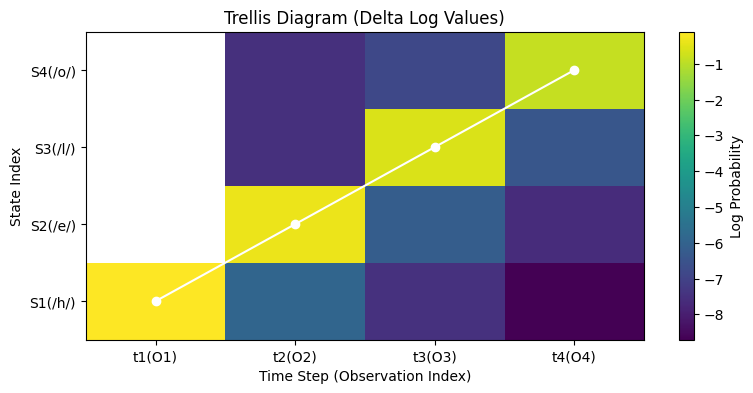

In [8]:
display(Markdown("## 3) Visualizations"))

plt.figure(figsize=(9,4))
plt.imshow(delta_log.T, aspect='auto', origin='lower')
plt.colorbar(label="Log Probability")
plt.title("Trellis Diagram (Delta Log Values)")
plt.xlabel("Time Step (Observation Index)")
plt.ylabel("State Index")
plt.xticks(range(4), ["t1(O1)", "t2(O2)", "t3(O3)", "t4(O4)"])
plt.yticks(range(4), states)
plt.plot(range(4), path_idx, marker='o', color='white')
plt.show()

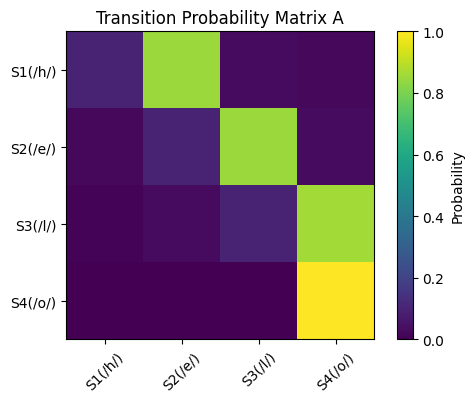

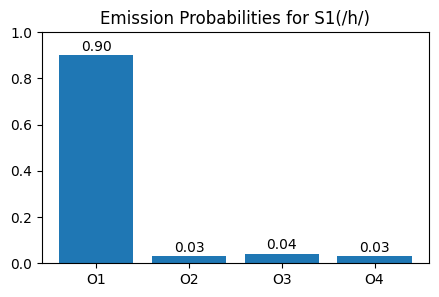

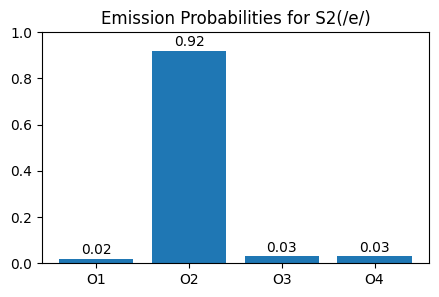

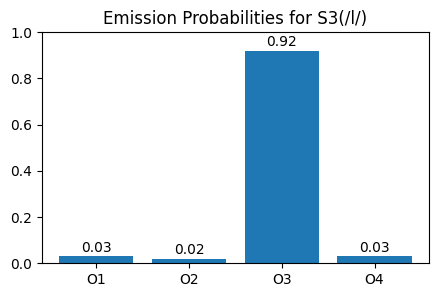

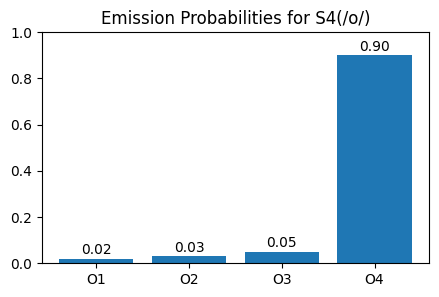

### Delta (log-probabilities) Table

,S1(/h/),S2(/e/),S3(/l/),S4(/o/)
0,-0.105361,-inf,-inf,-inf
1,-5.914504,-0.351261,-7.523941,-7.523941
2,-7.482160,-6.160404,-0.597162,-6.853551
3,-8.708890,-7.610277,-6.406305,-0.853345


In [9]:
plt.figure(figsize=(6,4))
plt.imshow(A, cmap="viridis")
plt.colorbar(label="Probability")
plt.title("Transition Probability Matrix A")
plt.xticks(range(4), states, rotation=45)
plt.yticks(range(4), states)
plt.show()

for i, st in enumerate(states):
    plt.figure(figsize=(5,3))
    plt.bar(observations, B[i])
    plt.title(f"Emission Probabilities for {st}")
    plt.ylim(0,1)
    for j, p in enumerate(B[i]):
        plt.text(j, p+0.02, f"{p:.2f}", ha="center")
    plt.show()

display(Markdown("### Delta (log-probabilities) Table"))
display(pd.DataFrame(delta_log, columns=states))

In [7]:
display(Markdown("## 4) Inference"))
display(Markdown(
f"""
**Decoded sequence:** {decoded_states}
This corresponds to phonemes: **/h/ → /e/ → /l/ → /o/**

✔ The Viterbi algorithm successfully identified the correct phoneme pattern for the word **'hello'**.
✔ The path has probability **{best_prob:.4f}**, indicating a strong match.
"""
))

## 4) Inference


**Decoded sequence:** ['S1(/h/)', 'S2(/e/)', 'S3(/l/)', 'S4(/o/)']  
This corresponds to phonemes: **/h/ → /e/ → /l/ → /o/**  

✔ The Viterbi algorithm successfully identified the correct phoneme pattern for the word **'hello'**.  
✔ The path has probability **0.4260**, indicating a strong match.  
